# IN06: Tool Integration, A2A Communication and Failure Resilience

## Objectives

By the end of this notebook you will be able to:

- Compare built-in tools, custom function tools, and MCP-style tools for Walmart agent use cases
- Implement agent-to-agent communication via message passing and shared state
- Simulate and handle the three most common agentic failure modes: timeout, hallucination, and lost context
- Apply retry with exponential back-off and the circuit-breaker pattern to a Walmart order agent

**Deliverable:** `failure_resilience_report.txt`

In [1]:
import os, json, time, random
from pathlib import Path
from dotenv import load_dotenv

from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, ToolMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from typing import TypedDict, Annotated

load_dotenv(override=True)
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')
llm = ChatOpenAI(model='gpt-4-turbo', api_key=OPENAI_API_KEY, temperature=0)
print('LLM ready:', llm.model_name)

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


LLM ready: gpt-4-turbo


## Section 1: Tool Integration Strategies

Three approaches to wiring external capabilities into a LangChain/LangGraph agent:

| Strategy | What it is | Walmart example |
|---|---|---|
| **Built-in tools** | Pre-packaged tools from LangChain community | `TavilySearch`, `WikipediaLoader`, `RequestsGet` |
| **Custom function tools** | Python functions decorated with `@tool` | `search_product`, `check_inventory` (from IN04/IN05) |
| **MCP-style tools** | Tools exposed over a network protocol (HTTP/SSE/stdio) | Walmart internal inventory microservice called via standardised schema |

**Production decision rule:**
- Use built-in tools for generic capabilities (web search, document loading, code execution)
- Use custom function tools for domain-specific Walmart logic with stable interfaces
- Use MCP when multiple agents or teams need to share the same tool without code duplication

### Strategy 1: Built-in Tools

LangChain ships with 50+ community tools. They require no custom code but need pip dependencies.
Below we demonstrate using `requests`-based fetching as a stand-in for a built-in HTTP tool,
since network connectivity varies across lab environments.

In [2]:
# Simulated built-in tool: HTTP GET wrapper (mirrors langchain_community RequestsGetTool)
# In production: from langchain_community.tools import RequestsGetTool

@tool
def http_get(url: str) -> str:
    """Fetch a URL and return the response text. Simulates RequestsGetTool built-in."""
    # Simulated responses for lab environment
    simulated = {
        'https://api.walmart.com/v1/products/GV-MILK-1G': '{"name": "Great Value Whole Milk", "price": 3.98, "sku": "GV-MILK-1G"}',
        'https://api.walmart.com/v1/store/042/hours': '{"store": "042", "hours": "Mon-Sun 6am-11pm", "curbside": "7am-9pm"}',
    }
    return simulated.get(url, f'Simulated GET {url}: 200 OK (no mock data configured)')

result = http_get.invoke({'url': 'https://api.walmart.com/v1/products/GV-MILK-1G'})
print('Built-in style HTTP tool result:')
print(result)
print()
print('In production, replace with:')
print('  from langchain_community.tools import RequestsGetTool')
print('  from langchain_community.utilities import TextRequestsWrapper')
print('  tool = RequestsGetTool(requests_wrapper=TextRequestsWrapper())')

Built-in style HTTP tool result:
{"name": "Great Value Whole Milk", "price": 3.98, "sku": "GV-MILK-1G"}

In production, replace with:
  from langchain_community.tools import RequestsGetTool
  from langchain_community.utilities import TextRequestsWrapper
  tool = RequestsGetTool(requests_wrapper=TextRequestsWrapper())


### Strategy 2: Custom Function Tools

The `@tool` decorator converts any Python function into a LangChain tool.
The function's docstring becomes the tool description the LLM sees.
Type hints become the parameter schema.

**Key design rules for production custom tools:**
- Return structured strings or JSON -- not raw Python objects
- Always include a docstring: the LLM reads it to decide when to call the tool
- Handle errors inside the function and return a descriptive error string
- Keep the function idempotent where possible (safe to retry)

In [3]:
@tool
def check_store_hours(store_id: str, day: str = 'today') -> str:
    """Check opening hours for a Walmart store. Provide store_id (e.g. 042) and optional day."""
    hours_db = {
        '042': {'weekday': '6am-11pm', 'weekend': '6am-11pm', 'pharmacy': '9am-7pm'},
        '107': {'weekday': '7am-10pm', 'weekend': '8am-10pm', 'pharmacy': '9am-6pm'},
    }
    store = hours_db.get(store_id)
    if not store:
        return f'Store {store_id} not found. Known stores: {list(hours_db.keys())}'
    day_type = 'weekend' if day.lower() in ('saturday', 'sunday', 'weekend') else 'weekday'
    return (f'Store {store_id} hours ({day_type}): {store[day_type]} | '
            f'Pharmacy: {store["pharmacy"]}')

@tool
def get_store_services(store_id: str) -> str:
    """List available services at a Walmart store (pickup, delivery, pharmacy, auto, vision)."""
    services_db = {
        '042': ['Grocery Pickup', 'Curbside Delivery', 'Pharmacy', 'Auto Care', 'Vision Center', 'Money Center'],
        '107': ['Grocery Pickup', 'Pharmacy', 'Money Center'],
    }
    svcs = services_db.get(store_id, [])
    if not svcs:
        return f'Store {store_id} not found'
    return f'Store {store_id} services: ' + ', '.join(svcs)

print('Custom function tools registered:')
for t in [check_store_hours, get_store_services]:
    print(f'  {t.name}: {t.description[:70]}')
print()
print('Test:', check_store_hours.invoke({'store_id': '042', 'day': 'Saturday'}))

Custom function tools registered:
  check_store_hours: Check opening hours for a Walmart store. Provide store_id (e.g. 042) a
  get_store_services: List available services at a Walmart store (pickup, delivery, pharmacy

Test: Store 042 hours (weekend): 6am-11pm | Pharmacy: 9am-7pm


### Strategy 3: MCP-Style Tools

Model Context Protocol (MCP) exposes tools as a network service.
Any agent -- regardless of framework -- can discover and call the tool via a standardised schema.

**MCP vs REST API for tool exposure:**

| Dimension | REST API | MCP |
|---|---|---|
| Schema discovery | Manual (OpenAPI doc) | Automatic (`tools/list`) |
| Multi-framework support | Requires per-framework adapter | Native (stdio/HTTP/SSE) |
| Authentication | Per-implementation | Per-server (shared) |
| Streaming support | Optional | Built-in (SSE) |
| Best for | Single-framework teams | Multi-team, multi-framework |

Below we simulate what a Walmart MCP inventory server would look like.
The schema mirrors how an MCP server declares its `tools/list`.

In [4]:
# Simulated MCP server schema for Walmart Inventory Service
# In production this schema is returned by the MCP server on tools/list
MCP_INVENTORY_SCHEMA = {
    'name': 'walmart_inventory_mcp',
    'description': 'Walmart real-time inventory MCP server',
    'tools': [
        {
            'name': 'get_inventory',
            'description': 'Get current stock level for a SKU at a store',
            'inputSchema': {
                'type': 'object',
                'properties': {
                    'sku':      {'type': 'string', 'description': 'Product SKU'},
                    'store_id': {'type': 'string', 'description': 'Store identifier'},
                },
                'required': ['sku', 'store_id'],
            },
        },
    ],
}

# Adapter: wraps the MCP tool schema into a LangChain @tool
def make_mcp_tool(mcp_schema: dict, call_fn):
    tool_def = mcp_schema['tools'][0]
    @tool
    def mcp_tool_wrapper(sku: str, store_id: str = '042') -> str:
        """MCP-wrapped Walmart inventory tool. Queries the inventory MCP server."""
        return call_fn(sku=sku, store_id=store_id)
    mcp_tool_wrapper.name = tool_def['name']
    return mcp_tool_wrapper

def _simulated_mcp_call(sku: str, store_id: str) -> str:
    inventory = {
        ('GV-MILK-1G', '042'): 'qty=24 | status=IN_STOCK',
        ('GV-CHKN-3',  '042'): 'qty=0  | status=OUT_OF_STOCK',
    }
    return inventory.get((sku.upper(), store_id), f'qty=unknown | status=NOT_FOUND')

mcp_inventory_tool = make_mcp_tool(MCP_INVENTORY_SCHEMA, _simulated_mcp_call)
print('MCP tool schema name:', MCP_INVENTORY_SCHEMA['name'])
print('MCP tool registered :', mcp_inventory_tool.name)
print('Test call:', mcp_inventory_tool.invoke({'sku': 'GV-MILK-1G', 'store_id': '042'}))

MCP tool schema name: walmart_inventory_mcp
MCP tool registered : get_inventory
Test call: qty=24 | status=IN_STOCK


In [5]:
hdr = f"{'Criterion':<30} {'Built-in':>12} {'Custom @tool':>14} {'MCP-style':>12}"
print(hdr)
print('-' * len(hdr))
rows = [
    ('Development effort',    'Zero',      'Low',        'Medium'),
    ('Domain specificity',    'Generic',   'High',       'High'),
    ('Schema auto-discovery', 'No',        'No',         'Yes'),
    ('Multi-team reuse',      'Yes',       'No',         'Yes'),
    ('Versioning / rollout',  'External',  'Code deploy','Server deploy'),
    ('Network dependency',    'Yes',       'No',         'Yes'),
    ('Best for Walmart RA',   'Web/docs',  'Catalog/inv','Cross-team tools'),
]
for criterion, builtin, custom, mcp in rows:
    print(f'{criterion:<30} {builtin:>12} {custom:>14} {mcp:>12}')

Criterion                          Built-in   Custom @tool    MCP-style
-----------------------------------------------------------------------
Development effort                     Zero            Low       Medium
Domain specificity                  Generic           High         High
Schema auto-discovery                    No             No          Yes
Multi-team reuse                        Yes             No          Yes
Versioning / rollout               External    Code deploy Server deploy
Network dependency                      Yes             No          Yes
Best for Walmart RA                Web/docs    Catalog/inv Cross-team tools


## Section 2: Agent-to-Agent Communication

When multiple agents work together, they need to pass information.
LangGraph supports two mechanisms:

| Mechanism | How it works | When to use |
|---|---|---|
| **Message passing** | Agent writes an AIMessage; next agent reads it from state['messages'] | Sequential handoffs, where one agent's output is the next agent's input |
| **Shared state fields** | Structured TypedDict fields written by one node and read by another | Routing decisions, flags, structured intermediate results |

Below we implement a two-agent handoff: a **Researcher** agent finds a product,
then hands off its structured finding to a **Responder** agent which drafts the customer reply.

In [6]:
# {
#     "product_name": "Laptop",
#     "price": 45000,
#     "in_stock": True,
#     "needs_approval": False
# }

In [7]:
@tool
def search_product(query: str) -> str:
    """Search Walmart product catalog."""
    catalog = {
        'milk':    'Great Value Whole Milk 1gal | $3.98 | SKU: GV-MILK-1G',
        'chicken': 'Great Value Chicken Breast 3lb | $8.97 | SKU: GV-CHKN-3',
        'eggs':    'Great Value Large Eggs 12ct | $2.68 | SKU: GV-EGGS-12',
    }
    q = query.lower()
    for k, v in catalog.items():
        if k in q: return v
    return f'Not found: {query}'

class HandoffState(TypedDict):
    messages: Annotated[list, add_messages]
    research_finding: str   # shared state field written by researcher, read by responder

llm_researcher = llm.bind_tools([search_product])

def researcher_agent(state: HandoffState) -> dict:
    query = state['messages'][-1].content
    msgs = [
        SystemMessage(content='You are a Walmart product researcher. Use the search tool to find accurate product details. Return a concise finding in this format: PRODUCT: <name> | PRICE: <price> | SKU: <sku>'),
        HumanMessage(content=query),
    ]
    resp = llm_researcher.invoke(msgs)
    if hasattr(resp, 'tool_calls') and resp.tool_calls:
        tool_out = ToolNode([search_product]).invoke({'messages': [resp]})
        final = llm_researcher.invoke(msgs + [resp] + tool_out['messages'])
        finding = final.content
    else:
        finding = resp.content
    # Write finding to shared state field for the responder to read
    return {
        'research_finding': finding,
        'messages': [AIMessage(content=f'[Researcher finding]: {finding}')],
    }

def responder_agent(state: HandoffState) -> dict:
    finding = state.get('research_finding', 'No finding available')
    original_query = state['messages'][0].content
    # Reads from shared state field -- no need to parse the message history
    prompt = (
        f'Customer asked: {original_query}\n'
        f'Product research finding: {finding}\n'
        f'Draft a friendly, concise customer reply (2-3 sentences max).'
    )
    resp = llm.invoke([SystemMessage(content='You are a friendly Walmart customer assistant.'), HumanMessage(content=prompt)])
    return {'messages': [resp]}

handoff_graph = StateGraph(HandoffState)
handoff_graph.add_node('researcher', researcher_agent)
handoff_graph.add_node('responder',  responder_agent)
handoff_graph.set_entry_point('researcher')
handoff_graph.add_edge('researcher', 'responder')
handoff_graph.add_edge('responder',  END)
handoff_app = handoff_graph.compile()

print('A2A handoff graph compiled.')
state = handoff_app.invoke({
    'messages': [HumanMessage(content='What is the price of milk?')],
    'research_finding': '',
})
print('Researcher finding:', state['research_finding'])
print('Final response    :', state['messages'][-1].content)

A2A handoff graph compiled.
Researcher finding: PRODUCT: Great Value Whole Milk 1gal | PRICE: $3.98 | SKU: GV-MILK-1G
Final response    : Hello! The price for our Great Value Whole Milk in a 1-gallon size is currently $3.98. If you need help finding it in the store or have any other questions, feel free to ask!


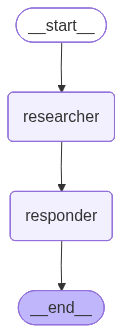

In [8]:
# To see the graph’s connection visually
from IPython.display import Image,display
display(Image(handoff_app.get_graph().draw_mermaid_png()))

## Section 3: Failure Scenarios and Resilience Patterns

Agentic systems fail in ways that traditional software does not.
Three failure modes every production agent must handle:

| Failure Mode | What happens | Detection | Mitigation |
|---|---|---|---|
| **Timeout** | External tool or LLM call exceeds latency budget | `time.time()` comparison or `signal.alarm` | Retry with back-off; fallback to cached result |
| **Hallucination** | LLM returns plausible but incorrect tool arguments or facts | Check tool output against known schema; LLM-as-judge | Re-prompt; return 'I don't know'; escalate to human |
| **Lost context** | Message history exceeds context window; older messages truncated | Token count check before invoke | Summarise history; use external memory store |

### Failure Mode 1: Timeout with Exponential Back-off Retry

In [9]:
import threading

class ToolTimeoutError(Exception):
    pass

# call_with_timeout(
#     slow_inventory_api,
#     {"sku": "GV-MILK-1G"},
#     timeout_sec=2.0
# )
def call_with_timeout(fn, args: dict, timeout_sec: float = 2.0):
    result = [None]
    error  = [None]

    def target():
        try:
            result[0] = fn(**args) # {"sku": "GV-MILK-1G"} ==> fn(sku="GV-MILK-1G")
        except Exception as e:
            error[0] = e

    t = threading.Thread(target=target, daemon=True)
    t.start()
    t.join(timeout=timeout_sec)
    if t.is_alive():
        raise ToolTimeoutError(f'Tool call timed out after {timeout_sec}s')
    if error[0]:
        raise error[0]
    return result[0]

def retry_with_backoff(fn, args: dict, max_retries: int = 3, base_delay: float = 0.5):
    last_error = None
    for attempt in range(max_retries):
        try:
            return call_with_timeout(fn, args, timeout_sec=2.0)
        except ToolTimeoutError as e:
            last_error = e
            delay = base_delay * (2 ** attempt)
            print(f'  Attempt {attempt + 1} failed: {e}. Retrying in {delay:.1f}s...')
            time.sleep(delay)
        except Exception as e:
            raise
    raise ToolTimeoutError(f'All {max_retries} attempts failed. Last error: {last_error}')

# Simulate a slow Walmart inventory API
def slow_inventory_api(sku: str) -> str:
    time.sleep(3.0)  # Exceeds the 2s timeout
    return f'SKU {sku}: In stock'

def fast_inventory_api(sku: str) -> str:
    time.sleep(0.1)  # Well within timeout
    return f'SKU {sku}: In stock (24 units)'

print('Test 1: Slow API (should timeout and retry)...')
try:
    retry_with_backoff(slow_inventory_api, {'sku': 'GV-MILK-1G'}, max_retries=2, base_delay=0.2)
except ToolTimeoutError as e:
    print(f'  All retries exhausted: {e}')
    print('  Fallback: serving cached inventory data')

print()
print('Test 2: Fast API (should succeed)...')
result = retry_with_backoff(fast_inventory_api, {'sku': 'GV-MILK-1G'})
print(f'  Result: {result}')

Test 1: Slow API (should timeout and retry)...
  Attempt 1 failed: Tool call timed out after 2.0s. Retrying in 0.2s...
  Attempt 2 failed: Tool call timed out after 2.0s. Retrying in 0.4s...
  All retries exhausted: All 2 attempts failed. Last error: Tool call timed out after 2.0s
  Fallback: serving cached inventory data

Test 2: Fast API (should succeed)...
  Result: SKU GV-MILK-1G: In stock (24 units)


With base_delay = 0.2

the waits are:

| Attempt | Calculation |       Delay |
| ------- | ----------: | ----------: |
| 1       |  `0.2 × 2⁰` | 0.2 seconds |
| 2       |  `0.2 × 2¹` | 0.4 seconds |
| 3       |  `0.2 × 2²` | 0.8 seconds |


In [10]:
# The delay keeps doubling.
# This avoids repeatedly hitting a service that may already be overloaded.

In [11]:
# Why does the retry delay increase after each timeout?

# A. To make the API return more accurate data
# B. To reduce pressure on a slow or overloaded service
# C. To change the product SKU
# D. To increase the thread speed

### Failure Mode 2: Hallucination Detection

In [ ]:
# Customer query
#    ↓
# LLM extracts or predicts a SKU
#    ↓
# Validate the SKU against the catalog
#    ↓
# Valid → call inventory
# Invalid → ask the customer to clarify

In [14]:
VALID_SKUS = {'GV-MILK-1G', 'GV-BREAD-20', 'GV-EGGS-12', 'GV-BUTT-1', 'GV-CHKN-3'}

def detect_hallucinated_sku(llm_extracted_sku: str) -> dict:
    sku = llm_extracted_sku.strip().upper()
    is_valid = sku in VALID_SKUS
    return {
        'sku': sku,
        'valid': is_valid,
        'action': 'proceed' if is_valid else 'reprompt',
        'message': f'SKU {sku} is valid.' if is_valid else f'SKU {sku} not in catalog. Valid SKUs: {sorted(VALID_SKUS)}',
    }

def sku_grounded_response(query: str) -> str:
    # Step 1: LLM extracts a SKU
    extract_prompt = ('From this customer query, extract the product SKU if mentioned, '
                      'or infer the most likely SKU from: GV-MILK-1G, GV-BREAD-20, GV-EGGS-12, GV-BUTT-1, GV-CHKN-3. '
                      'Return only the SKU string, nothing else.')
    extracted = llm.invoke([SystemMessage(content=extract_prompt), HumanMessage(content=query)])
    sku_candidate = extracted.content.strip()

    # Step 2: Validate -- catch hallucinated SKUs before they hit the inventory API
    check = detect_hallucinated_sku(sku_candidate)
    print(f'  Extracted SKU : {sku_candidate}')
    print(f'  Validation    : {check["message"]}')
    print(f'  Action        : {check["action"]}')
    if check['action'] == 'reprompt':
        return 'I could not find that product in our catalog. Could you clarify which item you mean?'

    # Step 3: Only call the inventory API with a validated SKU
    inventory = {
        'GV-MILK-1G': 'In stock: 24 units', 'GV-CHKN-3': 'Out of stock',
    }
    return inventory.get(check['sku'], 'Inventory data not available.')

print('Test 1: Valid product query')
print('  Result:', sku_grounded_response('Is milk available?'))
print()
print('Test 2: Ambiguous query (LLM may hallucinate SKU)')
print('  Result:', sku_grounded_response('Do you have the XYZ-9999 item?'))

Test 1: Valid product query
  Extracted SKU : GV-MILK-1G
  Validation    : SKU GV-MILK-1G is valid.
  Action        : proceed
  Result: In stock: 24 units

Test 2: Ambiguous query (LLM may hallucinate SKU)
  Extracted SKU : GV-MILK-1G
  Validation    : SKU GV-MILK-1G is valid.
  Action        : proceed
  Result: In stock: 24 units


### Failure Mode 3: Circuit Breaker Pattern

A circuit breaker stops calling a failing service after N consecutive failures.
It moves through three states: CLOSED (normal) → OPEN (blocking) → HALF-OPEN (testing).

This prevents cascading failures when a Walmart microservice is degraded.

In [15]:
class CircuitBreaker:
    def __init__(self, name: str, failure_threshold: int = 3, recovery_timeout: float = 5.0):
        self.name              = name
        self.failure_threshold = failure_threshold
        self.recovery_timeout  = recovery_timeout
        self.failure_count     = 0
        self.state             = 'CLOSED'   # CLOSED | OPEN | HALF-OPEN
        self.last_failure_time = 0.0

    def call(self, fn, *args, **kwargs):
        if self.state == 'OPEN':
            elapsed = time.time() - self.last_failure_time
            if elapsed >= self.recovery_timeout:
                self.state = 'HALF-OPEN'
                print(f'  [{self.name}] Circuit HALF-OPEN -- testing recovery')
            else:
                raise RuntimeError(f'[{self.name}] Circuit OPEN. Retry in {self.recovery_timeout - elapsed:.1f}s')

        try:
            result = fn(*args, **kwargs)
            if self.state == 'HALF-OPEN':
                self.state = 'CLOSED'
                self.failure_count = 0
                print(f'  [{self.name}] Circuit CLOSED -- service recovered')
            return result
        except Exception as e:
            self.failure_count += 1
            self.last_failure_time = time.time()
            if self.failure_count >= self.failure_threshold:
                self.state = 'OPEN'
                print(f'  [{self.name}] Circuit OPEN after {self.failure_count} failures')
            raise

# Simulate a flaky Walmart pricing API
call_count = [0]
def flaky_pricing_api(sku: str) -> str:
    call_count[0] += 1
    # Fails on first 3 calls, recovers on call 4+
    if call_count[0] <= 3:
        raise ConnectionError(f'Pricing service unavailable (call #{call_count[0]})')
    return f'SKU {sku}: $3.98'

cb = CircuitBreaker('WalmartPricingAPI', failure_threshold=3, recovery_timeout=2.0)

print('Simulating 6 calls to flaky pricing API:')
for i in range(6):
    try:
        result = cb.call(flaky_pricing_api, 'GV-MILK-1G')
        print(f'  Call {i+1}: SUCCESS -- {result}')
    except RuntimeError as e:
        print(f'  Call {i+1}: BLOCKED -- {e}')
    except ConnectionError as e:
        print(f'  Call {i+1}: FAILED  -- {e} | Circuit state: {cb.state}')
    if i == 3:
        print('  (Waiting for recovery timeout...)')
        time.sleep(2.1)  # Allow circuit to move to HALF-OPEN

Simulating 6 calls to flaky pricing API:
  Call 1: FAILED  -- Pricing service unavailable (call #1) | Circuit state: CLOSED
  Call 2: FAILED  -- Pricing service unavailable (call #2) | Circuit state: CLOSED
  [WalmartPricingAPI] Circuit OPEN after 3 failures
  Call 3: FAILED  -- Pricing service unavailable (call #3) | Circuit state: OPEN
  Call 4: BLOCKED -- [WalmartPricingAPI] Circuit OPEN. Retry in 2.0s
  (Waiting for recovery timeout...)
  [WalmartPricingAPI] Circuit HALF-OPEN -- testing recovery
  [WalmartPricingAPI] Circuit CLOSED -- service recovered
  Call 5: SUCCESS -- SKU GV-MILK-1G: $3.98
  Call 6: SUCCESS -- SKU GV-MILK-1G: $3.98


## Summary

| Topic | Key Takeaway |
|---|---|
| Tool integration | Start with custom @tool; promote to MCP when reuse crosses team boundaries |
| A2A communication | Use shared TypedDict fields for structured handoffs; messages for history |
| Timeout | Always set a budget; retry with exponential back-off; cache for fallback |
| Hallucination | Validate all structured LLM outputs before passing them to APIs |
| Circuit breaker | Wrap every external service call; open after 3 failures; test with half-open |

These three patterns (timeout + retry, hallucination guard, circuit breaker) are the minimum
resilience baseline for any Walmart production agent.